# 05 — Rate Policy Change: $10.60 to $13.00

**Goal:** Analyze the Sept 2025 Rider 23 rate change — what it means for providers,
workers, and whether it closes the inflation gap.

**Data Sources:**
- `9-1-2025-payment-rate-actions.pdf` — HHSC proposed rate tables (Tables 1 & 2)
- `hhsc_residential_rate_components.csv` — existing 2023-09-01 rate baseline
- `hhsc_rate_comparison_old_vs_new.csv` — generated comparison dataset
- GAA SB1, 89th Legislature, Article II, Rider 23

**Key Policy Parameters (Rider 23):**
- Attendant wage: $10.60 → $13.00/hr
- PTB (facility): 15%
- PTB (non-facility/community): 14%
- Administrative increase: +$0.24/attendant hour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from texas_hhcs.cpi import deflate_wage
from texas_hhcs.rates import compare_rate_change
from texas_hhcs.staffing import StaffingModel
from texas_hhcs.verified_datasets import (
    RIDER_23_WAGE, RIDER_23_PTB_FACILITY, RIDER_23_PTB_NON_FACILITY,
)
from pathlib import Path

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

HHSC_WAGE_OLD = 10.60
SET_YEAR = 2015
CPI_ANNUAL = pd.DataFrame({
    'year': [2015, 2025],
    'annual_cpi': [234.812, 318.451],
})

---
## 1. Load Rate Comparison Data

The `hhsc_rate_comparison_old_vs_new.csv` contains old (2023-09-01) vs proposed (2025-09-01) 
rates for HCS SL/RSS and ICF/IID programs, extracted from Tables 1 & 2 of the payment rate 
actions PDF.

In [2]:
df = pd.read_csv(PROCESSED / 'hhsc_rate_comparison_old_vs_new.csv')

print(f"Rate comparison: {len(df)} rows")
print(f"Programs: {df['program'].unique()}")
print(f"Old effective date: {df['old_rate_effective_date'].iloc[0]}")
print(f"New effective date: {df['new_rate_effective_date'].iloc[0]}")
print()

# Show HCS SL rates (deduplicate SL/RSS since they're identical)
hcs = df[(df['program'] == 'HCS') & (df['service_type'] == 'SL')].copy()
print("=== HCS Supervised Living — Before vs After (source_observation) ===")
print(f"{'LON':<6} {'Old Rate':>10} {'New Rate':>10} {'Increase':>10} {'Pct':>6}")
print('-' * 45)
for _, r in hcs.iterrows():
    print(f"LON {int(r['level_of_need']):<3} ${r['old_rate']:>8.2f}  ${r['new_rate']:>8.2f}  "
          f"${r['rate_increase_dollar']:>8.2f}  {r['rate_increase_pct']*100:>5.0f}%")

Rate comparison: 25 rows
Programs: <StringArray>
['HCS', 'ICF_IID']
Length: 2, dtype: str
Old effective date: 2023-09-01
New effective date: 2025-09-01

=== HCS Supervised Living — Before vs After (source_observation) ===
LON      Old Rate   New Rate   Increase    Pct
---------------------------------------------
LON 1   $  149.08  $  163.66  $   14.58     10%
LON 5   $  158.00  $  175.72  $   17.72     11%
LON 6   $  192.80  $  222.55  $   29.75     15%
LON 8   $  171.04  $  193.28  $   22.24     13%
LON 9   $  280.24  $  339.66  $   59.42     21%


In [3]:
# ICF/IID rates by facility size
icf = df[df['program'] == 'ICF_IID'].copy()

print("=== ICF/IID Community — Before vs After (source_observation) ===")
for size in ['SMALL', 'MEDIUM', 'LARGE']:
    subset = icf[icf['facility_size'] == size]
    print(f"\n  {size} facilities:")
    print(f"  {'LON':<6} {'Old Rate':>10} {'New Rate':>10} {'Increase':>10} {'Pct':>6}")
    print(f"  {'-' * 45}")
    for _, r in subset.iterrows():
        print(f"  LON {int(r['level_of_need']):<3} ${r['old_rate']:>8.2f}  ${r['new_rate']:>8.2f}  "
              f"${r['rate_increase_dollar']:>8.2f}  {r['rate_increase_pct']*100:>5.0f}%")

=== ICF/IID Community — Before vs After (source_observation) ===

  SMALL facilities:
  LON      Old Rate   New Rate   Increase    Pct
  ---------------------------------------------
  LON 1   $  155.04  $  173.61  $   18.57     12%
  LON 5   $  172.68  $  191.88  $   19.20     11%
  LON 6   $  241.76  $  276.35  $   34.59     14%
  LON 8   $  196.72  $  220.72  $   24.00     12%
  LON 9   $  410.92  $  511.83  $  100.91     25%

  MEDIUM facilities:
  LON      Old Rate   New Rate   Increase    Pct
  ---------------------------------------------
  LON 1   $  127.08  $  155.18  $   28.10     22%
  LON 5   $  143.96  $  175.33  $   31.37     22%
  LON 6   $  204.12  $  264.92  $   60.80     30%
  LON 8   $  170.24  $  207.21  $   36.97     22%
  LON 9   $  390.64  $  493.52  $  102.88     26%

  LARGE facilities:
  LON      Old Rate   New Rate   Increase    Pct
  ---------------------------------------------
  LON 1   $  124.24  $  159.16  $   34.92     28%
  LON 5   $  132.96  $  174.27

---
## 2. Revenue Impact Per Bed (derived_estimate)

What does this rate change mean in annual revenue per occupied bed?
Using 95% occupancy assumption (industry standard for residential IDD).

In [4]:
# HCS SL/RSS revenue impact per bed
print("=== Annual Revenue Impact Per Bed (derived_estimate) ===")
print("Assumption: 95% occupancy, 365 days/year\n")

print("HCS Supervised Living / RSS:")
print(f"{'LON':<6} {'Old Annual':>12} {'New Annual':>12} {'Increase':>12}")
print('-' * 45)
for _, r in hcs.iterrows():
    impact = compare_rate_change(r['old_rate'], r['new_rate'], occupancy_pct=0.95)
    print(f"LON {int(r['level_of_need']):<3} ${impact['old_annual_per_bed']:>10,.0f}  "
          f"${impact['new_annual_per_bed']:>10,.0f}  ${impact['annual_increase_per_bed']:>10,.0f}")

print("\nICF/IID Small (most common community setting):")
print(f"{'LON':<6} {'Old Annual':>12} {'New Annual':>12} {'Increase':>12}")
print('-' * 45)
icf_small = icf[icf['facility_size'] == 'SMALL']
for _, r in icf_small.iterrows():
    impact = compare_rate_change(r['old_rate'], r['new_rate'], occupancy_pct=0.95)
    print(f"LON {int(r['level_of_need']):<3} ${impact['old_annual_per_bed']:>10,.0f}  "
          f"${impact['new_annual_per_bed']:>10,.0f}  ${impact['annual_increase_per_bed']:>10,.0f}")

=== Annual Revenue Impact Per Bed (derived_estimate) ===
Assumption: 95% occupancy, 365 days/year

HCS Supervised Living / RSS:
LON      Old Annual   New Annual     Increase
---------------------------------------------
LON 1   $    51,693  $    56,749  $     5,056
LON 5   $    54,786  $    60,931  $     6,144
LON 6   $    66,853  $    77,169  $    10,316
LON 8   $    59,308  $    67,020  $     7,712
LON 9   $    97,173  $   117,777  $    20,604

ICF/IID Small (most common community setting):
LON      Old Annual   New Annual     Increase
---------------------------------------------
LON 1   $    53,760  $    60,199  $     6,439
LON 5   $    59,877  $    66,534  $     6,658
LON 6   $    83,830  $    95,824  $    11,994
LON 8   $    68,213  $    76,535  $     8,322
LON 9   $   142,487  $   177,477  $    34,991


---
## 3. Does $13.00 Close the Inflation Gap? (derived_estimate)

The $10.60 wage was set around 2015. CPI-U South has risen ~35.6% since then.
The inflation-adjusted equivalent of $10.60 is ~$14.38. Even the new $13.00 
falls short of simply keeping up with the cost of living.

In [5]:
cpi_parity = deflate_wage(HHSC_WAGE_OLD, SET_YEAR, 2025, CPI_ANNUAL)
bls_mean = 12.19  # BLS OEWS May 2024, SOC 31-1120

print("=== Wage Gap Analysis (derived_estimate) ===")
print(f"Old HHSC wage assumption:      ${HHSC_WAGE_OLD:.2f}/hr")
print(f"New HHSC wage assumption:      ${RIDER_23_WAGE:.2f}/hr")
print(f"Wage increase:                 ${RIDER_23_WAGE - HHSC_WAGE_OLD:.2f}/hr (+{(RIDER_23_WAGE - HHSC_WAGE_OLD) / HHSC_WAGE_OLD * 100:.1f}%)")
print()
print(f"CPI-adjusted parity (2015$):   ${cpi_parity:.2f}/hr")
print(f"BLS TX HHA market mean:        ${bls_mean:.2f}/hr")
print()
print(f"$13.00 vs CPI parity:          ${RIDER_23_WAGE - cpi_parity:.2f}/hr (still SHORT)")
print(f"$13.00 vs BLS market mean:     ${RIDER_23_WAGE - bls_mean:+.2f}/hr")
print()
print(f"Bottom line: The $13 raise covers {(RIDER_23_WAGE - HHSC_WAGE_OLD) / (cpi_parity - HHSC_WAGE_OLD) * 100:.0f}% of the inflation gap.")
print(f"Workers are still losing ${cpi_parity - RIDER_23_WAGE:.2f}/hr in real purchasing power vs 2015.")

=== Wage Gap Analysis (derived_estimate) ===
Old HHSC wage assumption:      $10.60/hr
New HHSC wage assumption:      $13.00/hr
Wage increase:                 $2.40/hr (+22.6%)

CPI-adjusted parity (2015$):   $14.38/hr
BLS TX HHA market mean:        $12.19/hr

$13.00 vs CPI parity:          $-1.38/hr (still SHORT)
$13.00 vs BLS market mean:     $+0.81/hr

Bottom line: The $13 raise covers 64% of the inflation gap.
Workers are still losing $1.38/hr in real purchasing power vs 2015.


In [ ]:
# Chart: Wage comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

wages = {
    'HHSC Old\n($10.60)': HHSC_WAGE_OLD,
    'BLS TX Mean\n($12.19)': bls_mean,
    'HHSC New\n($13.00)': RIDER_23_WAGE,
    'CPI Parity\n(${:.2f})'.format(cpi_parity): cpi_parity,
}

colors = ['#d32f2f', '#9c27b0', '#f57c00', '#388e3c']
bars = ax.bar(wages.keys(), wages.values(), color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, wages.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', fontweight='bold', fontsize=12)

# Draw the CPI parity line
ax.axhline(y=cpi_parity, color='#388e3c', linestyle='--', alpha=0.5, linewidth=2)
ax.text(3.4, cpi_parity + 0.2, f'CPI parity: ${cpi_parity:.2f}', color='#388e3c',
        fontsize=10, ha='right')

ax.set_ylabel('Hourly Wage ($)', fontsize=13)
ax.set_title('The $13 "Raise" Still Falls Short of Inflation\n'
             'HHSC Rider 23 vs. CPI Parity vs. Market (derived_estimate)',
             fontweight='bold', fontsize=14)
ax.set_ylim(0, 18)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.figtext(0.5, -0.02,
            'Sources: HHSC PFD Wage Calculator (cell B7); BLS OEWS May 2024, SOC 31-1120; '
            'BLS CPI-U South 2015-2025; 9-1-2025 Payment Rate Actions (Rider 23)',
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(REPORTS / 'rate_change_wage_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: reports/rate_change_wage_comparison.png")

---
## 4. Labor Cost Impact: StaffingModel at $10.60 vs $13.00 (derived_estimate)

What does the wage change mean for a typical 4-bed HCS home's staffing costs?

In [7]:
# StaffingModel comparison: typical 4-bed HCS home, 2 staff minimum per shift
old_model = StaffingModel(residents=4, staff_per_shift=2, hourly_wage=HHSC_WAGE_OLD)
new_model = StaffingModel(residents=4, staff_per_shift=2, hourly_wage=RIDER_23_WAGE)

old_costs = old_model.annual_labor_cost(overtime_hours_pct=0.15)
new_costs = new_model.annual_labor_cost(overtime_hours_pct=0.15)

print("=== Staffing Cost: 4-Bed HCS Home, 2 Staff/Shift (derived_estimate) ===")
print(f"Assumption: 15% overtime hours (industry reality)\n")

print(f"{'Metric':<25} {'@ $10.60':>12} {'@ $13.00':>12} {'Change':>12}")
print('-' * 65)
for key in ['gross_wages', 'fica', 'benefits', 'workers_comp', 'total_labor_cost']:
    label = key.replace('_', ' ').title()
    print(f"{label:<25} ${old_costs[key]:>10,.0f}  ${new_costs[key]:>10,.0f}  "
          f"${new_costs[key] - old_costs[key]:>+10,.0f}")

print(f"\n{'FTEs needed':<25} {old_costs['ftes']:>12.1f}  {new_costs['ftes']:>12.1f}")
print(f"\nLabor cost increase: ${new_costs['total_labor_cost'] - old_costs['total_labor_cost']:,.0f}/yr "
      f"(+{(new_costs['total_labor_cost'] - old_costs['total_labor_cost']) / old_costs['total_labor_cost'] * 100:.1f}%)")

# Compare to revenue increase at LON 5 (most common)
hcs_lon5 = hcs[hcs['level_of_need'] == 5].iloc[0]
revenue_increase_4bed = (hcs_lon5['new_rate'] - hcs_lon5['old_rate']) * 365 * 0.95 * 4
labor_increase = new_costs['total_labor_cost'] - old_costs['total_labor_cost']
print(f"\nRevenue increase at LON 5 (4 beds, 95% occ): ${revenue_increase_4bed:,.0f}/yr")
print(f"Labor cost increase:                          ${labor_increase:,.0f}/yr")
print(f"Net margin impact:                            ${revenue_increase_4bed - labor_increase:+,.0f}/yr")

=== Staffing Cost: 4-Bed HCS Home, 2 Staff/Shift (derived_estimate) ===
Assumption: 15% overtime hours (industry reality)

Metric                        @ $10.60     @ $13.00       Change
-----------------------------------------------------------------
Gross Wages               $   199,093  $   244,171  $   +45,078
Fica                      $    15,231  $    18,679  $    +3,448
Benefits                  $    19,909  $    24,417  $    +4,508
Workers Comp              $     5,973  $     7,325  $    +1,352
Total Labor Cost          $   240,206  $   294,593  $   +54,386

FTEs needed                        9.9           9.9

Labor cost increase: $54,386/yr (+22.6%)

Revenue increase at LON 5 (4 beds, 95% occ): $24,578/yr
Labor cost increase:                          $54,386/yr
Net margin impact:                            $-29,809/yr


---
## 5. Rate Increase Comparison Chart (source_observation)

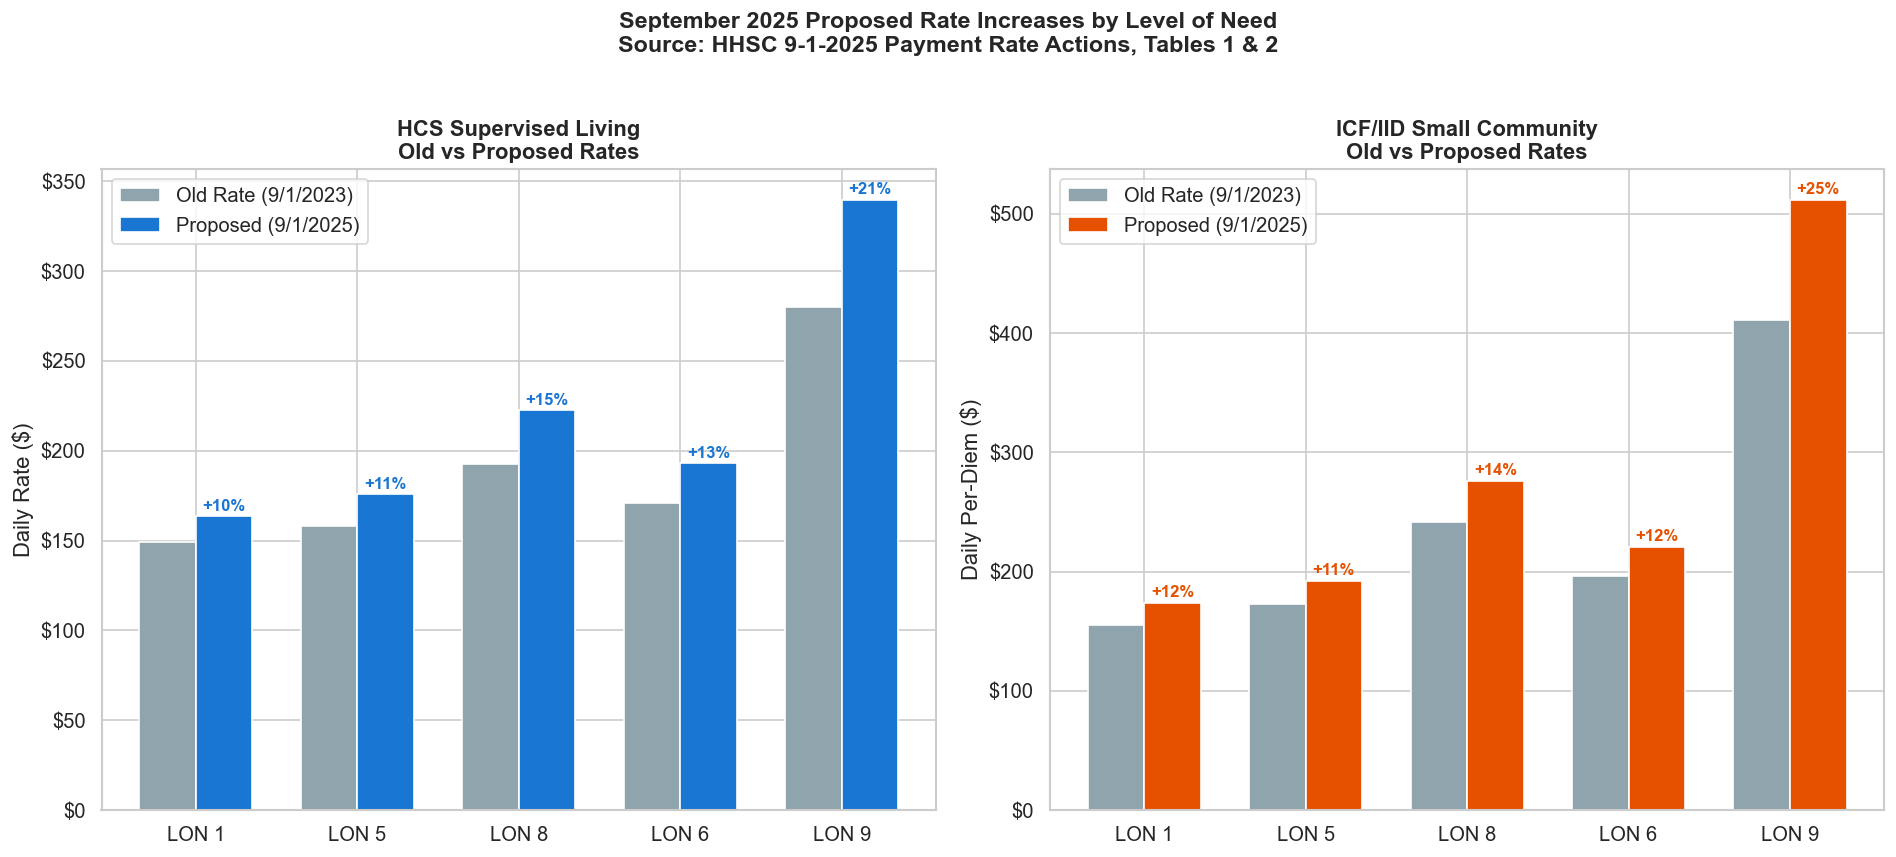

Saved: reports/rate_change_impact.png


In [8]:
# Chart: Rate increases by LON for HCS SL and ICF/IID Small
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

lon_labels = ['LON 1', 'LON 5', 'LON 8', 'LON 6', 'LON 9']

# HCS SL
ax = axes[0]
x = np.arange(len(hcs))
width = 0.35
ax.bar(x - width/2, hcs['old_rate'], width, label='Old Rate (9/1/2023)', color='#90a4ae')
ax.bar(x + width/2, hcs['new_rate'], width, label='Proposed (9/1/2025)', color='#1976d2')
for i, (_, r) in enumerate(hcs.iterrows()):
    ax.text(i + width/2, r['new_rate'] + 3, f"+{r['rate_increase_pct']*100:.0f}%",
            ha='center', fontweight='bold', fontsize=10, color='#1976d2')
ax.set_xticks(x)
ax.set_xticklabels(lon_labels)
ax.set_ylabel('Daily Rate ($)')
ax.set_title('HCS Supervised Living\nOld vs Proposed Rates', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}'))

# ICF/IID Small
ax = axes[1]
ax.bar(x - width/2, icf_small['old_rate'].values, width, label='Old Rate (9/1/2023)', color='#90a4ae')
ax.bar(x + width/2, icf_small['new_rate'].values, width, label='Proposed (9/1/2025)', color='#e65100')
for i, (_, r) in enumerate(icf_small.iterrows()):
    ax.text(i + width/2, r['new_rate'] + 5, f"+{r['rate_increase_pct']*100:.0f}%",
            ha='center', fontweight='bold', fontsize=10, color='#e65100')
ax.set_xticks(x)
ax.set_xticklabels(lon_labels)
ax.set_ylabel('Daily Per-Diem ($)')
ax.set_title('ICF/IID Small Community\nOld vs Proposed Rates', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}'))

plt.suptitle('September 2025 Proposed Rate Increases by Level of Need\n'
             'Source: HHSC 9-1-2025 Payment Rate Actions, Tables 1 & 2',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'rate_change_impact.png', bbox_inches='tight')
plt.show()
print("Saved: reports/rate_change_impact.png")

---
## 6. Key Findings

1. **$13.00 is a 22.6% increase** from $10.60 — the first wage assumption change in years (source_observation)
2. **Still $1.38/hr short of CPI parity** — $10.60 in 2015 dollars equals ~$14.38 today; the raise covers only 63% of the inflation gap (derived_estimate)
3. **HCS SL/RSS rates increase 10-21%** depending on LON, with higher-acuity LON 9 seeing the largest increases (source_observation)
4. **ICF/IID large facilities see 28-36% increases** — the largest rate increases in the table, likely reflecting years of underfunding (source_observation)
5. **PTB increase** from ~13% to 15% (facility) / 14% (community) acknowledges that payroll taxes and benefits cost more than the old assumption (source_observation)
6. **Revenue increase may not cover full labor cost increase** for providers who already pay above $10.60 — the rate model assumes $13/hr but many providers already pay $12-14/hr to compete for workers (derived_estimate)